# L1_m9 rotation groups: tSZ power spectra per shell group, theory, and feedback variants

Like notebook 39 for L2p8_m9, but for the L1_m9 box: the yang26 lightcone re-rotates
after every rotation group, and for L1 there are **13 groups** over shells 0-59
($z < 3$; group 0 is the identity rotation).  Group maps are plain sums of the
unlensed per-shell ComptonY maps (no rotation applied; the power spectrum is
rotation-invariant), built by `scripts/build_rotation_group_maps.py --parent L1_m9`
for all nine feedback prescriptions and stored in
`/rds/rds-lxu/flamingo/L1_m9/maps/rotation_groups/`.

$D_\ell$ measurements (anafast `iter=0`, pixel window deconvolved, $f_{\rm sky}$
corrected, monopole subtracted; nb39 conventions) are cached per variant by
`scripts/export_L1_m9_rotation_group_tsz_ps.py` in
`data/nb40_l1_m9_rotation_group_tsz_ps/`.

Theory: hmfast halo model with the A10 GNFW pressure profile, $B=1$ (nb05
conventions), integrated over each group's $[z_{\rm inner}, z_{\rm outer}]$.

In [1]:
import os
import sys
from pathlib import Path

os.environ.setdefault("JAX_PLATFORMS", "cpu")

REPO = Path("/scratch/scratch-lxu/flamingo_repo")
sys.path.insert(0, str(REPO / "src"))

import numpy as np
import matplotlib.pyplot as plt
import jax.numpy as jnp

from flamingo.catalogue import D3A_COSMOLOGY
from hmfast.halos import HaloModel
from hmfast.halos.profiles import GNFWPressureProfile
from hmfast.tracers import tSZTracer

plt.rcParams.update({
    "text.usetex": False,
    "font.family": "serif",
    "font.size": 11,
    "axes.labelsize": 12,
    "axes.titlesize": 11,
    "legend.fontsize": 8,
    "figure.dpi": 100,
    "savefig.dpi": 300,
})

DATA_DIR = REPO / "data/nb40_l1_m9_rotation_group_tsz_ps"
FIG_DIR = REPO / "figures/nb40_l1_m9_rotation_group_tsz_ps"
FIG_DIR.mkdir(parents=True, exist_ok=True)

LMAX = 6000
N_Z_BINS = 60
A10_B1 = dict(P0=8.403, c500=1.177, gamma=0.3081, alpha=1.0510, beta=5.4905)

VARIANTS = [
    "L1_m9",
    "fgas+2sigma",
    "fgas-2sigma",
    "fgas-4sigma",
    "fgas-8sigma",
    "Mstar-1sigma",
    "Mstar-1sigma_fgas-4sigma",
    "Jet",
    "Jet_fgas-4sigma",
]

LABELS = {
    "L1_m9": "fiducial (L1_m9)",
    "fgas+2sigma": "fgas +2$\\sigma$",
    "fgas-2sigma": "fgas $-$2$\\sigma$",
    "fgas-4sigma": "fgas $-$4$\\sigma$",
    "fgas-8sigma": "fgas $-$8$\\sigma$",
    "Mstar-1sigma": "M$_*$ $-$1$\\sigma$",
    "Mstar-1sigma_fgas-4sigma": "M$_*$ $-$1$\\sigma$, fgas $-$4$\\sigma$",
    "Jet": "Jet",
    "Jet_fgas-4sigma": "Jet + fgas $-$4$\\sigma$",
}
VARIANT_COLORS = dict(zip(VARIANTS, plt.cm.tab10(np.linspace(0, 0.95, len(VARIANTS)))))


def log_bin(ell, dl, lmin=10, lmax=LMAX, nbin=30):
    edges = np.logspace(np.log10(lmin), np.log10(lmax), nbin + 1)
    idx = np.digitize(ell, edges) - 1
    lb, db = [], []
    for b in range(nbin):
        sel = (idx == b) & (ell >= lmin)
        if sel.any():
            lb.append(ell[sel].mean())
            db.append(dl[sel].mean())
    return np.array(lb), np.array(db)


def rot_label(theta, phi):
    if theta == 0.0 and phi == 0.0:
        return "identity"
    return rf"$\theta={theta:.3f}$, $\phi={phi:.3f}$"


## Load cached spectra

One `.npz` per variant: `dl` is `(13, lmax+1)`, plus combined sums `dl_all`
(all groups) and `dl_g1plus` (groups 1-12, identity group 0 excluded).

In [2]:
spectra = {}
for variant in VARIANTS:
    d = np.load(DATA_DIR / f"{variant}.npz")
    spectra[variant] = {k: d[k] for k in d.files}

fid = spectra["L1_m9"]
ell = fid["ell"]
n_groups = fid["dl"].shape[0]
z_inner, z_outer = fid["z_inner"], fid["z_outer"]
print(f"{n_groups} rotation groups, variants: {list(spectra)}")
for gi in range(n_groups):
    print(
        f"group {gi:2d}  shells {fid['shell_first'][gi]:2d}-{fid['shell_last'][gi]:2d}  "
        f"z=[{z_inner[gi]:.3f},{z_outer[gi]:.3f}]  "
        f"theta={fid['rot_theta_rad'][gi]:.5f} phi={fid['rot_phi_rad'][gi]:.5f}"
    )

13 rotation groups, variants: ['L1_m9', 'fgas+2sigma', 'fgas-2sigma', 'fgas-4sigma', 'fgas-8sigma', 'Mstar-1sigma', 'Mstar-1sigma_fgas-4sigma', 'Jet', 'Jet_fgas-4sigma']
group  0  shells  0- 1  z=[0.001,0.100]  theta=0.00000 phi=0.00000
group  1  shells  2- 4  z=[0.100,0.250]  theta=3.26758 phi=1.41519
group  2  shells  5- 6  z=[0.250,0.350]  theta=1.51290 phi=0.80580
group  3  shells  7- 9  z=[0.350,0.500]  theta=3.13886 phi=0.71831
group  4  shells 10-13  z=[0.500,0.700]  theta=2.17061 phi=1.77537
group  5  shells 14-16  z=[0.700,0.850]  theta=4.59421 phi=0.62435
group  6  shells 17-20  z=[0.850,1.050]  theta=1.14274 phi=2.14077
group  7  shells 21-24  z=[1.050,1.250]  theta=2.02717 phi=0.49841
group  8  shells 25-29  z=[1.250,1.500]  theta=2.77675 phi=2.01363
group  9  shells 30-35  z=[1.500,1.800]  theta=0.83245 phi=2.25357
group 10  shells 36-42  z=[1.800,2.150]  theta=4.95779 phi=1.85187
group 11  shells 43-50  z=[2.150,2.550]  theta=2.52360 phi=1.36014
group 12  shells 51-59  z=

## Theory: hmfast A10 GNFW $B=1$ per group redshift range (nb05 conventions)

In [3]:
hm = HaloModel(cosmology=D3A_COSMOLOGY)
ell_th = jnp.logspace(1.0, np.log10(LMAX), 40)
m_grid = jnp.logspace(11.0, 15.5, 60)
pref = np.asarray(ell_th) * (np.asarray(ell_th) + 1) / (2 * np.pi)


def theory_dl(zlo, zhi, n_z_bins=N_Z_BINS):
    """tSZ D_l from hmfast (nb05): A10 GNFW B=1, geomspace z over [zlo, zhi]."""
    z = jnp.geomspace(max(zlo, 0.001), zhi, n_z_bins)
    profile = GNFWPressureProfile(**A10_B1, B=1.0)
    tracer = tSZTracer(profile=profile)
    cl1 = np.asarray(hm.cl_1h(tracer, tracer, l=ell_th, m=m_grid, z=z))
    cl2 = np.asarray(hm.cl_2h(tracer, tracer, l=ell_th, m=m_grid, z=z))
    return pref * (cl1 + cl2)


dth_groups = [theory_dl(z_inner[gi], z_outer[gi]) for gi in range(n_groups)]
dth_all = theory_dl(z_inner[0], z_outer[-1])
dth_g1p = theory_dl(z_inner[1], z_outer[-1])

for gi in range(n_groups):
    d300_m = np.interp(3000, ell, fid["dl"][gi])
    d300_t = np.interp(3000, np.asarray(ell_th), dth_groups[gi])
    print(f"group {gi:2d}  D_3000 meas={d300_m:.2e}  theory={d300_t:.2e}")

group  0  D_3000 meas=8.26e-15  theory=1.60e-14
group  1  D_3000 meas=1.49e-13  theory=2.10e-13
group  2  D_3000 meas=1.95e-13  theory=2.22e-13
group  3  D_3000 meas=3.10e-13  theory=3.28e-13
group  4  D_3000 meas=3.24e-13  theory=3.33e-13
group  5  D_3000 meas=1.86e-13  theory=1.66e-13
group  6  D_3000 meas=1.62e-13  theory=1.38e-13
group  7  D_3000 meas=1.01e-13  theory=7.76e-14
group  8  D_3000 meas=6.85e-14  theory=5.03e-14
group  9  D_3000 meas=4.11e-14  theory=2.70e-14
group 10  D_3000 meas=2.01e-14  theory=1.25e-14
group 11  D_3000 meas=8.86e-15  theory=5.11e-15
group 12  D_3000 meas=3.50e-15  theory=1.95e-15


## Fiducial L1_m9: per-group $D_\ell$ vs theory (13 panels)

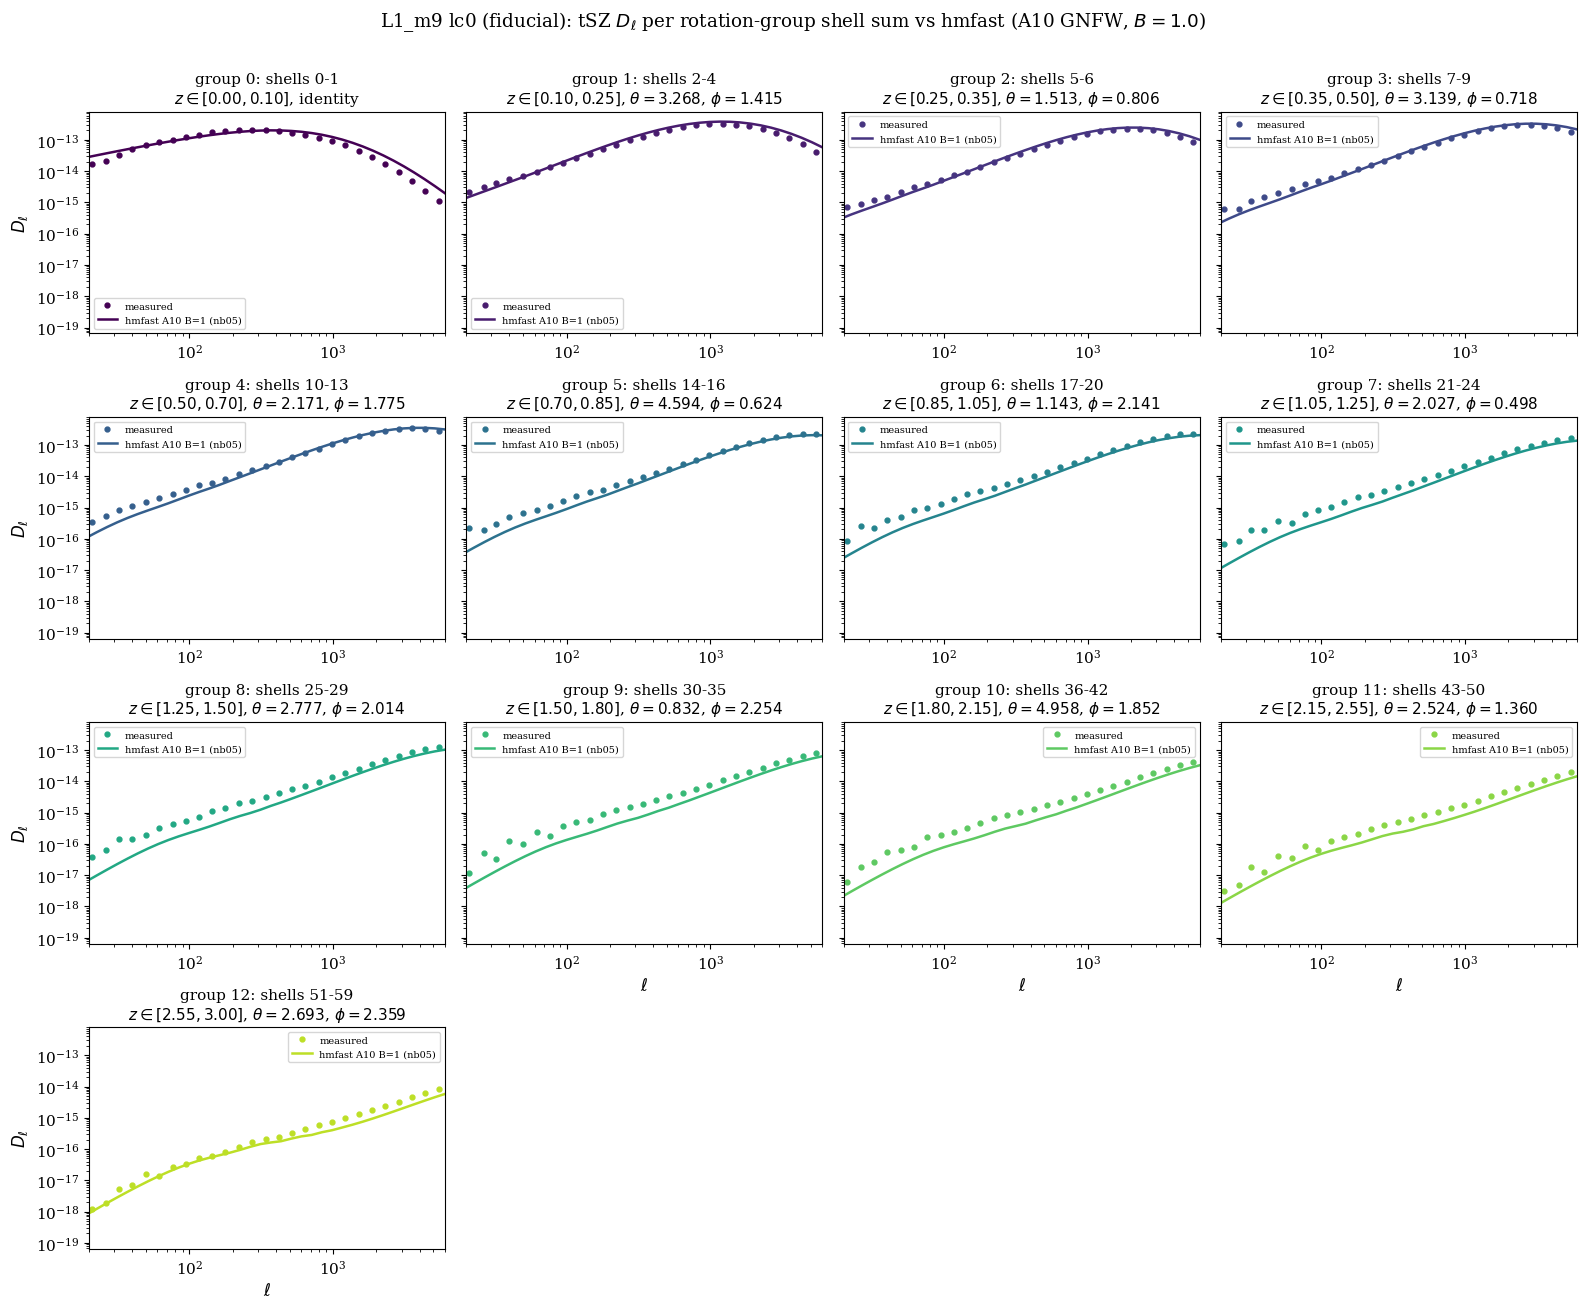

Saved to /scratch/scratch-lxu/flamingo_repo/figures/nb40_l1_m9_rotation_group_tsz_ps


In [4]:
group_colors = plt.cm.viridis(np.linspace(0.0, 0.9, n_groups))

fig, axes = plt.subplots(4, 4, figsize=(16, 13), sharex=True, sharey=True)
axes = axes.ravel()

for gi in range(n_groups):
    ax = axes[gi]
    col = group_colors[gi]
    ellb, dlb = log_bin(ell, fid["dl"][gi])
    ax.plot(ellb, dlb, "o", ms=3.5, color=col, label="measured")
    ax.plot(np.asarray(ell_th), dth_groups[gi], "-", lw=1.8, color=col,
            label="hmfast A10 B=1 (nb05)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(20, LMAX)
    sh = f"{fid['shell_first'][gi]}-{fid['shell_last'][gi]}"
    ax.set_title(
        rf"group {gi}: shells {sh}"
        "\n"
        rf"$z \in [{z_inner[gi]:.2f}, {z_outer[gi]:.2f}]$, "
        + rot_label(fid["rot_theta_rad"][gi], fid["rot_phi_rad"][gi])
    )
    ax.legend(fontsize=7)

for ax in axes[:n_groups]:
    ax.tick_params(labelbottom=True)
for gi in range(n_groups):
    if gi % 4 == 0:
        axes[gi].set_ylabel(r"$D_\ell$")
    if gi >= n_groups - 4:
        axes[gi].set_xlabel(r"$\ell$")
for ax in axes[n_groups:]:
    ax.axis("off")

fig.suptitle(
    r"L1_m9 lc0 (fiducial): tSZ $D_\ell$ per rotation-group shell sum vs hmfast (A10 GNFW, $B=1.0$)",
    y=1.005,
)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"rotation_group_tsz_ps_13panel.{ext}", bbox_inches="tight")
plt.show()
print("Saved to", FIG_DIR)

## Fiducial: all groups overlaid

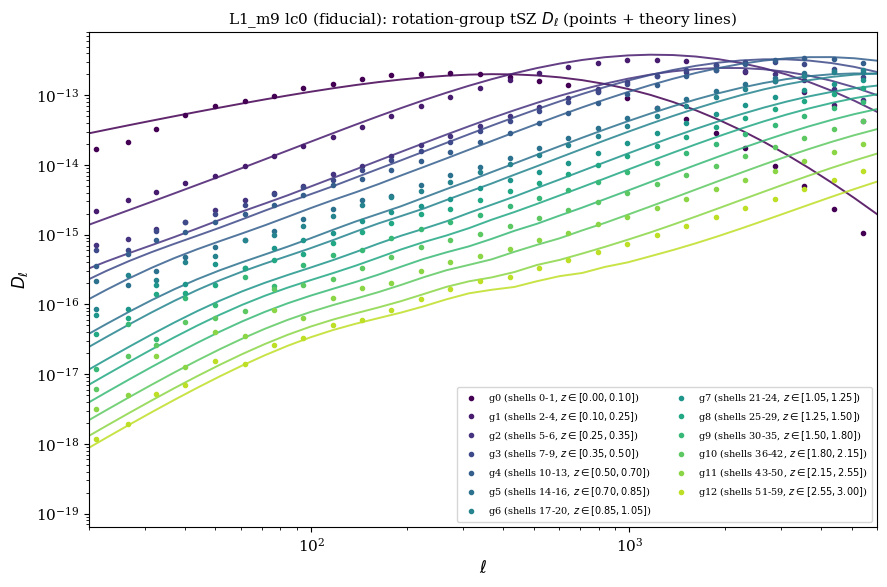

In [5]:
fig, ax = plt.subplots(figsize=(9, 6))
for gi in range(n_groups):
    col = group_colors[gi]
    ellb, dlb = log_bin(ell, fid["dl"][gi])
    sh = f"{fid['shell_first'][gi]}-{fid['shell_last'][gi]}"
    ax.plot(ellb, dlb, "o", ms=3, color=col,
            label=rf"g{gi} (shells {sh}, $z \in [{z_inner[gi]:.2f},{z_outer[gi]:.2f}]$)")
    ax.plot(np.asarray(ell_th), dth_groups[gi], "-", lw=1.4, color=col, alpha=0.85)

ax.set_xscale("log")
ax.set_yscale("log")
ax.set_xlim(20, LMAX)
ax.set_xlabel(r"$\ell$")
ax.set_ylabel(r"$D_\ell$")
ax.set_title(r"L1_m9 lc0 (fiducial): rotation-group tSZ $D_\ell$ (points + theory lines)")
ax.legend(fontsize=7, ncol=2)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"rotation_group_tsz_ps_overlay.{ext}", bbox_inches="tight")
plt.show()

## Fiducial: combined sums vs theory

Sum of all 13 group maps (full lightcone, $z<3$) and of groups 1-12
(identity group 0 excluded, as in nb39).

all groups 0-12: z=[0.001,3.000]  D_3000 meas=1.55e-12  theory=1.59e-12
groups 1-12 (shells 2-59, exclude group 0): z=[0.100,3.000]  D_3000 meas=1.54e-12  theory=1.57e-12


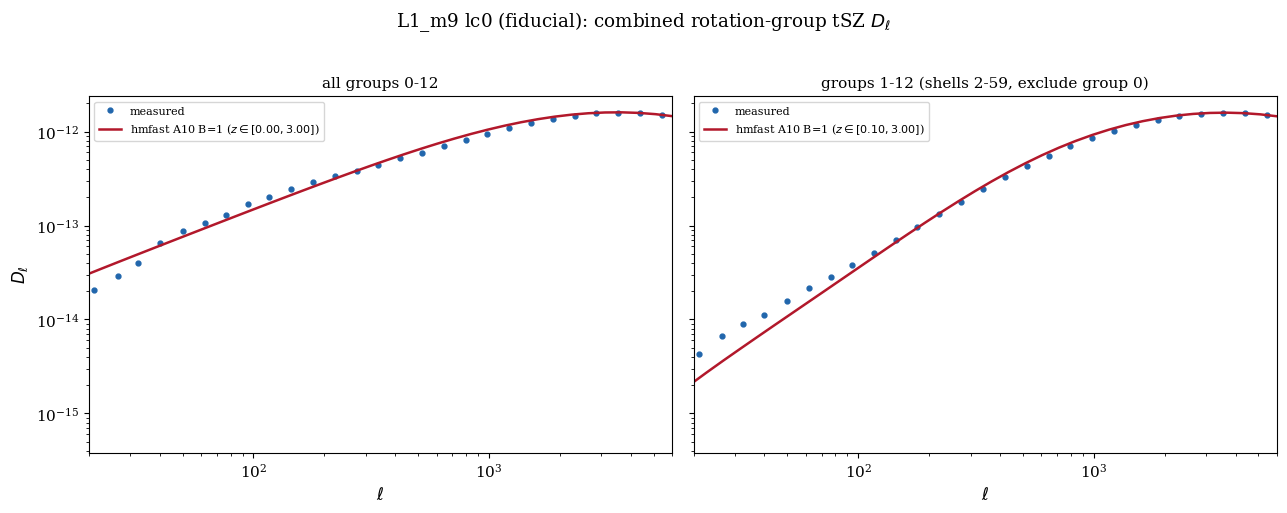

In [6]:
combos = [
    ("dl_all", dth_all, (z_inner[0], z_outer[-1]), "all groups 0-12"),
    ("dl_g1plus", dth_g1p, (z_inner[1], z_outer[-1]),
     f"groups 1-12 (shells {fid['shell_first'][1]}-{fid['shell_last'][-1]}, exclude group 0)"),
]

fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
for ax, (key, dth, (zlo, zhi), title) in zip(axes, combos):
    ellb, dlb = log_bin(ell, fid[key])
    d300_m = np.interp(3000, ell, fid[key])
    d300_t = np.interp(3000, np.asarray(ell_th), dth)
    print(f"{title}: z=[{zlo:.3f},{zhi:.3f}]  D_3000 meas={d300_m:.2e}  theory={d300_t:.2e}")
    ax.plot(ellb, dlb, "o", ms=3.5, color="#2166ac", label="measured")
    ax.plot(np.asarray(ell_th), dth, "-", lw=1.8, color="#b2182b",
            label=rf"hmfast A10 B=1 ($z \in [{zlo:.2f},{zhi:.2f}]$)")
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(20, LMAX)
    ax.set_xlabel(r"$\ell$")
    ax.set_title(title)
    ax.legend(fontsize=8)
axes[0].set_ylabel(r"$D_\ell$")
fig.suptitle(r"L1_m9 lc0 (fiducial): combined rotation-group tSZ $D_\ell$", y=1.02)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"rotation_group_sum_combined_2panel.{ext}", bbox_inches="tight")
plt.show()

## Feedback prescriptions: per-group $D_\ell$ for all nine variants

Each panel shows the binned measured spectra of the nine feedback variants for
one rotation group, with the fiducial-redshift-range hmfast theory (A10 GNFW,
$B=1$; independent of the feedback prescription) as the dashed black line.

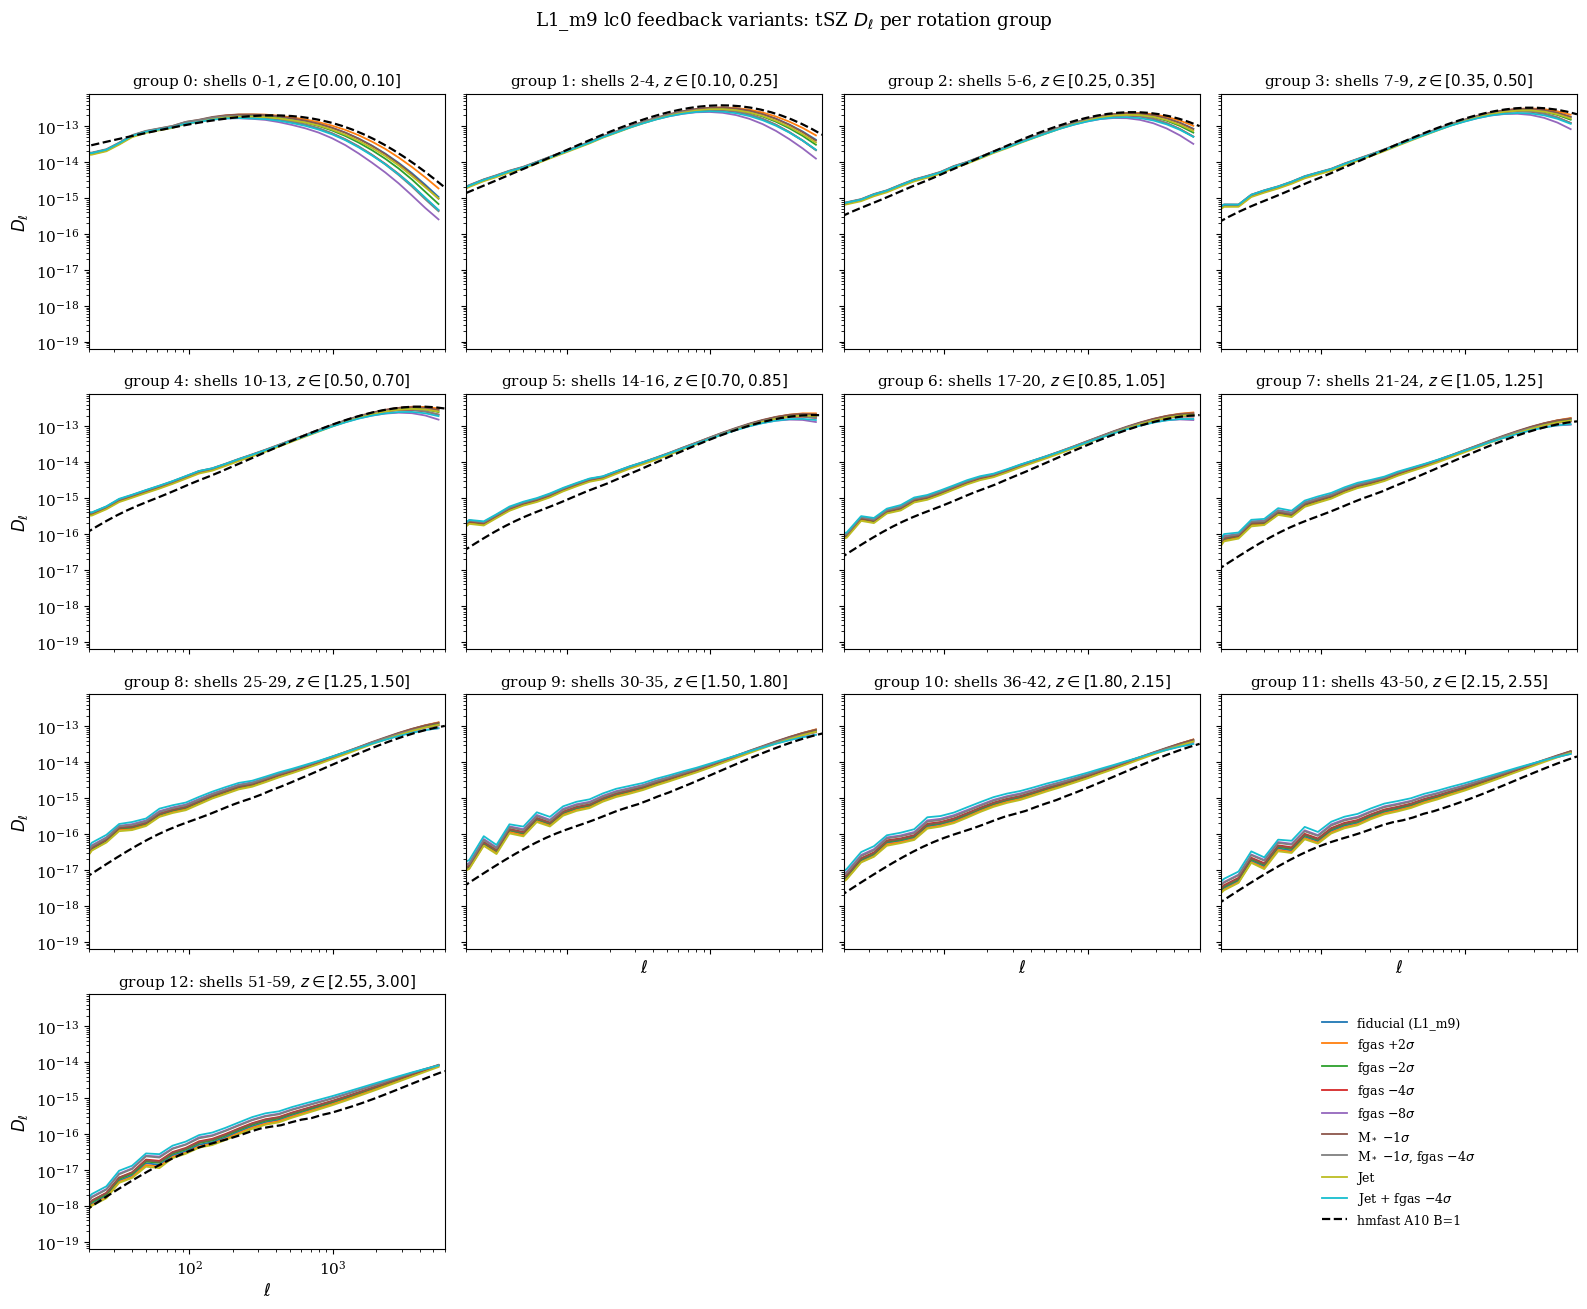

In [7]:
fig, axes = plt.subplots(4, 4, figsize=(16, 13), sharex=True, sharey=True)
axes = axes.ravel()

for gi in range(n_groups):
    ax = axes[gi]
    for variant in VARIANTS:
        ellb, dlb = log_bin(ell, spectra[variant]["dl"][gi])
        ax.plot(ellb, dlb, "-", lw=1.3, color=VARIANT_COLORS[variant],
                label=LABELS[variant] if gi == 0 else None)
    ax.plot(np.asarray(ell_th), dth_groups[gi], "k--", lw=1.6,
            label="hmfast A10 B=1" if gi == 0 else None)
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(20, LMAX)
    sh = f"{fid['shell_first'][gi]}-{fid['shell_last'][gi]}"
    ax.set_title(rf"group {gi}: shells {sh}, $z \in [{z_inner[gi]:.2f}, {z_outer[gi]:.2f}]$")
    if gi % 4 == 0:
        ax.set_ylabel(r"$D_\ell$")
    if gi >= n_groups - 4:
        ax.set_xlabel(r"$\ell$")

for ax in axes[n_groups:]:
    ax.axis("off")
handles, labels_ = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels_, loc="center", fontsize=9, frameon=False)

fig.suptitle(
    r"L1_m9 lc0 feedback variants: tSZ $D_\ell$ per rotation group",
    y=1.005,
)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"rotation_group_feedback_13panel.{ext}", bbox_inches="tight")
plt.show()

## Feedback prescriptions: ratio to fiducial per group

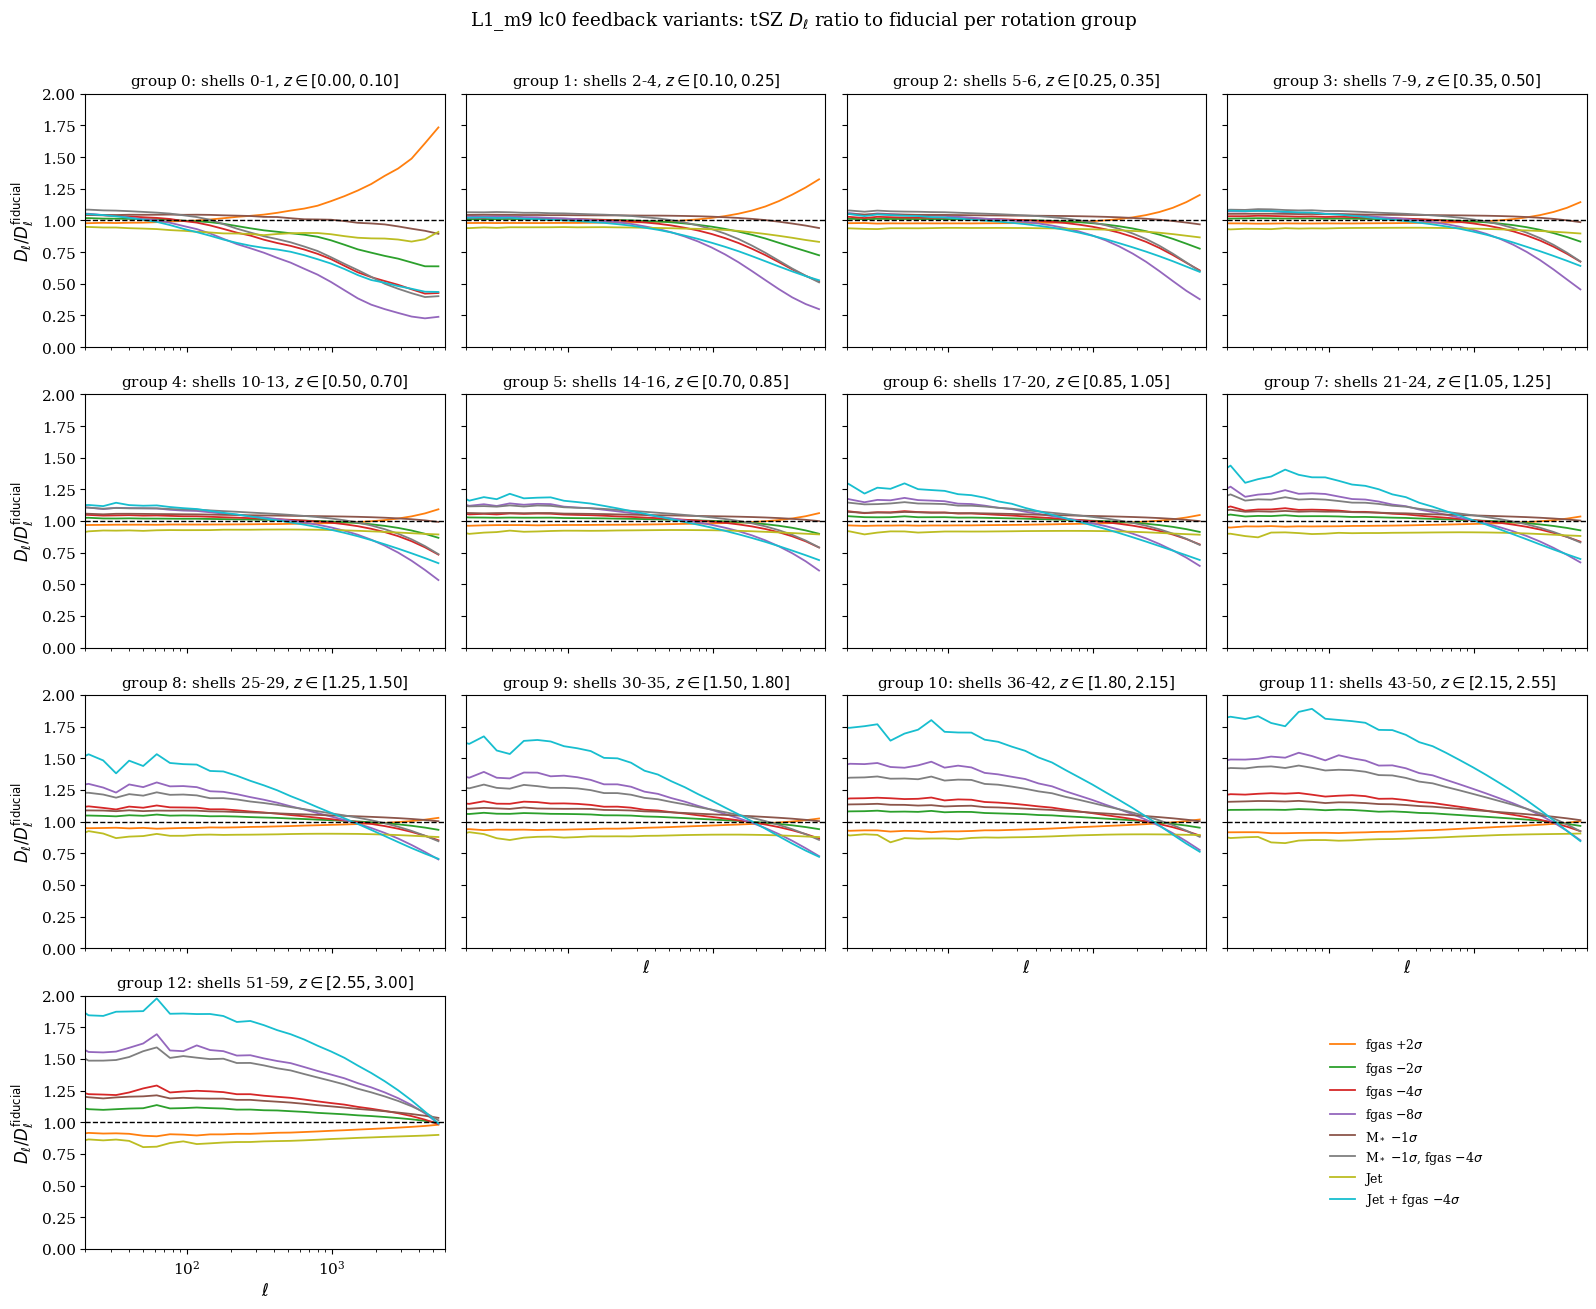

Saved to /scratch/scratch-lxu/flamingo_repo/figures/nb40_l1_m9_rotation_group_tsz_ps


In [8]:
fig, axes = plt.subplots(4, 4, figsize=(16, 13), sharex=True, sharey=True)
axes = axes.ravel()

for gi in range(n_groups):
    ax = axes[gi]
    ellb_f, dlb_f = log_bin(ell, fid["dl"][gi])
    for variant in VARIANTS[1:]:
        ellb, dlb = log_bin(ell, spectra[variant]["dl"][gi])
        ax.plot(ellb, dlb / dlb_f, "-", lw=1.3, color=VARIANT_COLORS[variant],
                label=LABELS[variant] if gi == 0 else None)
    ax.axhline(1.0, color="k", ls="--", lw=1.0)
    ax.set_xscale("log")
    ax.set_xlim(20, LMAX)
    ax.set_ylim(0, 2.0)
    sh = f"{fid['shell_first'][gi]}-{fid['shell_last'][gi]}"
    ax.set_title(rf"group {gi}: shells {sh}, $z \in [{z_inner[gi]:.2f}, {z_outer[gi]:.2f}]$")
    if gi % 4 == 0:
        ax.set_ylabel(r"$D_\ell / D_\ell^{\rm fiducial}$")
    if gi >= n_groups - 4:
        ax.set_xlabel(r"$\ell$")

for ax in axes[n_groups:]:
    ax.axis("off")
handles, labels_ = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels_, loc="center", fontsize=9, frameon=False)

fig.suptitle(
    r"L1_m9 lc0 feedback variants: tSZ $D_\ell$ ratio to fiducial per rotation group",
    y=1.005,
)
fig.tight_layout()
for ext in ("png", "pdf"):
    fig.savefig(FIG_DIR / f"rotation_group_feedback_ratio_13panel.{ext}", bbox_inches="tight")
plt.show()
print("Saved to", FIG_DIR)